In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)



Dataset extracted to: /content/dataset


In [3]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt


In [4]:
dataset_path = "/content/dataset/Dataset"


In [5]:
img_size = 224
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 80000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [6]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)


In [8]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [10]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/efficientnet_fake_real_best.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[checkpoint, earlystop]
)


Epoch 1/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.4989 - loss: 0.6974
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to /content/drive/MyDrive/efficientnet_fake_real_best.h5


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 1179s 463ms/step - accuracy: 0.4989 - loss: 0.6974 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.4978 - loss: 0.6933
Epoch 2: val_accuracy did not improve from 0.50000
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 1145s 458ms/step - accuracy: 0.4978 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.5017 - loss: 0.6932
Epoch 3: val_accuracy did not improve from 0.50000
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 1137s 455ms/step - accuracy: 0.5017 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.5010 - loss: 0.6932
Epoch 4: val_accuracy improved from 0.50000 to 0.57910, saving model to /content/drive/MyDrive/efficientnet_fake_real_best.h5


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 1114s 446ms/step - accuracy: 0.5010 - loss: 0.6932 - val_accuracy: 0.5791 - val_loss: 0.6931
Epoch 5/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.4985 - loss: 0.6932
Epoch 5: val_accuracy did not improve from 0.57910
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 1134s 454ms/step - accuracy: 0.4985 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.4998 - loss: 0.6932
Epoch 6: val_accuracy did not improve from 0.57910
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 1119s 447ms/step - accuracy: 0.4998 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931


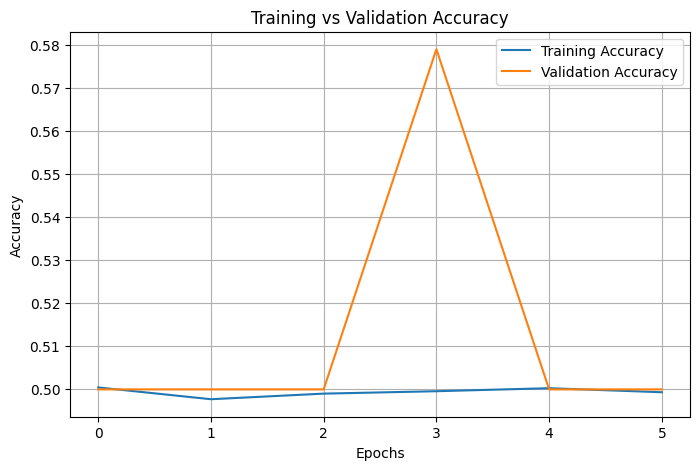

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

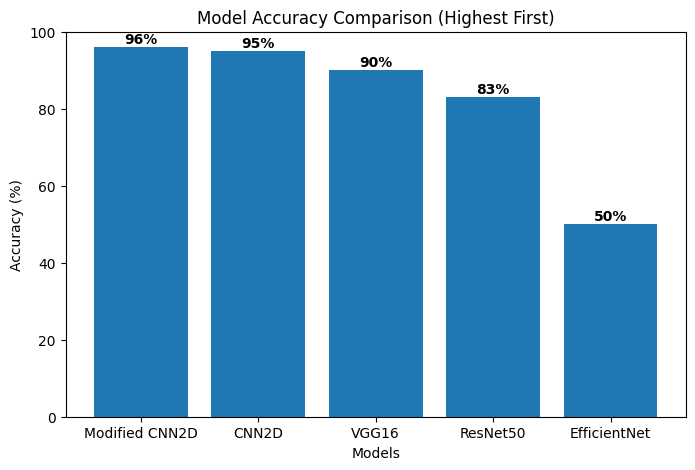

In [2]:
import matplotlib.pyplot as plt

# Sorted model names (highest accuracy first)
models = ['Modified CNN2D', 'CNN2D', 'VGG16', 'ResNet50', 'EfficientNet']

# Corresponding accuracy values
accuracies = [96, 95, 90, 83, 50]

# Create bar chart
plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison (Highest First)")
plt.ylim(0, 100)

# Display values on bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, str(v) + "%", ha='center', fontweight='bold')

plt.show()
